In [154]:
!pip install pandas matplotlib seaborn scikit-learn

In [155]:
# importing necessary libraries
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

In [156]:
df = pd.read_csv('Bengaluru_House_Data.csv')
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [157]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [158]:
df = df.drop(["area_type", "availability", "society", "balcony"], axis=1)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13319 non-null  str    
 1   size        13304 non-null  str    
 2   total_sqft  13320 non-null  str    
 3   bath        13247 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), str(3)
memory usage: 520.4 KB


In [159]:
# handling missing values in location
display(df['location'].value_counts())
df['location'] = df['location'].fillna('Sarjapur Road')
df.info()

location
Whitefield                                         540
Sarjapur  Road                                     399
Electronic City                                    302
Kanakpura Road                                     273
Thanisandra                                        234
                                                  ... 
Pattegarhpalya                                       1
Tilak Nagar                                          1
12th cross srinivas nagar banshankari 3rd stage      1
Havanur extension                                    1
Abshot Layout                                        1
Name: count, Length: 1305, dtype: int64

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13320 non-null  str    
 1   size        13304 non-null  str    
 2   total_sqft  13320 non-null  str    
 3   bath        13247 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), str(3)
memory usage: 520.4 KB


In [160]:
# handling missing values in size
display(df['size'].value_counts()) # 2BHK is more
df['size'] = df['size'].fillna('2 BHK')
df.info()

size
2 BHK         5199
3 BHK         4310
4 Bedroom      826
4 BHK          591
3 Bedroom      547
1 BHK          538
2 Bedroom      329
5 Bedroom      297
6 Bedroom      191
1 Bedroom      105
8 Bedroom       84
7 Bedroom       83
5 BHK           59
9 Bedroom       46
6 BHK           30
7 BHK           17
1 RK            13
10 Bedroom      12
9 BHK            8
8 BHK            5
11 BHK           2
11 Bedroom       2
10 BHK           2
27 BHK           1
19 BHK           1
16 BHK           1
43 Bedroom       1
14 BHK           1
12 Bedroom       1
13 BHK           1
18 Bedroom       1
Name: count, dtype: int64

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13320 non-null  str    
 1   size        13320 non-null  str    
 2   total_sqft  13320 non-null  str    
 3   bath        13247 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), str(3)
memory usage: 520.4 KB


In [161]:
# handling missing values in bath
df['bath'] = df['bath'].fillna(df['bath'].median())
# replaces all missing values in bath column with the median value of the column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13320 non-null  str    
 1   size        13320 non-null  str    
 2   total_sqft  13320 non-null  str    
 3   bath        13320 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), str(3)
memory usage: 520.4 KB


In [162]:
# clean size column and convert to integer
df['size'].unique()
out = [int(i.split()[0]) for i in df['size']]
df['bhk'] = out # new column created with only number of bedrooms
# df.info()
df['bhk']

0        2
1        4
2        3
3        3
4        2
        ..
13315    5
13316    4
13317    2
13318    4
13319    1
Name: bhk, Length: 13320, dtype: int64

In [163]:
# outliers
df[df['bhk'] > 20]

,location,size,total_sqft,bath,price,bhk
1718,2Electronic City Phase II,27 BHK,8000,27.0,230.0,27
4684,Munnekollal,43 Bedroom,2400,40.0,660.0,43


In [164]:
# clean total_sqft column
df['total_sqft'].unique()

def convert(a):
    if isinstance(a, str):
        i = a.split('-')
        if len(i) == 2:
            return (float(i[0]) + float(i[1])) / 2
    try:
        return float(a)
    except (ValueError, TypeError):
        return None

df['total_sqft'] = df['total_sqft'].apply(convert)
df['total_sqft']

# apply() runs convert() function on every value in the total_sqrt column

0        1056.0
1        2600.0
2        1440.0
3        1521.0
4        1200.0
          ...  
13315    3453.0
13316    3600.0
13317    1141.0
13318    4689.0
13319     550.0
Name: total_sqft, Length: 13320, dtype: float64

In [165]:
# price per sqft
df['price_per_sqft'] = df['price'] * 100000 / df['total_sqft'] # price in lakhs
# instead of comparing houses by total price, we compare them by price per sqft
df['price_per_sqft']

0         3699.810606
1         4615.384615
2         4305.555556
3         6245.890861
4         4250.000000
             ...     
13315     6689.834926
13316    11111.111111
13317     5258.545136
13318    10407.336319
13319     3090.909091
Name: price_per_sqft, Length: 13320, dtype: float64

In [166]:
df.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000


In [167]:
df.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,13274.000000,13320.000000,13320.000000,13320.000000,1.327400e+04
mean,1559.626694,2.688814,112.565627,2.802778,7.907501e+03
std,1238.405258,1.338754,148.971674,1.294496,1.064296e+05
min,1.000000,1.000000,8.000000,1.000000,2.678298e+02
25%,1100.000000,2.000000,50.000000,2.000000,4.266865e+03
50%,1276.000000,2.000000,72.000000,3.000000,5.434306e+03
75%,1680.000000,3.000000,120.000000,3.000000,7.311746e+03
max,52272.000000,40.000000,3600.000000,43.000000,1.200000e+07


In [168]:
# cleaning location column
df['location'] = df['location'].apply(lambda x: x.strip())
df['location'].value_counts()

loc_lessthan_10 = df['location'].value_counts()
loc_lessthan_10 = loc_lessthan_10[loc_lessthan_10 <= 10]
loc_lessthan_10

location
Ganga Nagar                                        10
Dairy Circle                                       10
Sadashiva Nagar                                    10
Naganathapura                                      10
Nagappa Reddy Layout                               10
                                                   ..
Pattegarhpalya                                      1
Tilak Nagar                                         1
12th cross srinivas nagar banshankari 3rd stage     1
Havanur extension                                   1
Abshot Layout                                       1
Name: count, Length: 1054, dtype: int64

In [169]:
df['location'] = df['location'].apply(lambda x: 'Other' if x in loc_lessthan_10 else x)
# groups all locations that occur fewer than 10 times into a single category called 'Other'
df['location'].value_counts()

location
Other                        2886
Whitefield                    541
Sarjapur  Road                399
Electronic City               304
Kanakpura Road                273
                             ... 
Tindlu                         11
2nd Phase Judicial Layout      11
Marsur                         11
Thyagaraja Nagar               11
HAL 2nd Stage                  11
Name: count, Length: 242, dtype: int64

In [170]:
# outliers in total_sqft column
df.describe() # count, mean, std dev, min, max, quartile 1, quartile 2, median

,total_sqft,bath,price,bhk,price_per_sqft
count,13274.000000,13320.000000,13320.000000,13320.000000,1.327400e+04
mean,1559.626694,2.688814,112.565627,2.802778,7.907501e+03
std,1238.405258,1.338754,148.971674,1.294496,1.064296e+05
min,1.000000,1.000000,8.000000,1.000000,2.678298e+02
25%,1100.000000,2.000000,50.000000,2.000000,4.266865e+03
50%,1276.000000,2.000000,72.000000,3.000000,5.434306e+03
75%,1680.000000,3.000000,120.000000,3.000000,7.311746e+03
max,52272.000000,40.000000,3600.000000,43.000000,1.200000e+07


In [171]:
# Min value is 1, we can't have a BHK room with 1 sqft, it is unrealistic and outlier

# total_sqft per bhk
(df['total_sqft'] / df['bhk']).describe()
# avg sqft available per BHK

count    13274.000000
mean       575.074878
std        388.205175
min          0.250000
25%        473.333333
50%        552.500000
75%        625.000000
max      26136.000000
dtype: float64

In [172]:
# fetch the data where total_sqft per bhk is more than 300
df = df[(df['total_sqft'] / df['bhk']) >= 300]
df.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,12530.000000,12530.000000,12530.000000,12530.000000,12530.000000
mean,1594.564544,2.559537,111.382401,2.650838,6303.979357
std,1261.271296,1.077938,152.077329,0.976678,4162.237981
min,300.000000,1.000000,8.440000,1.000000,267.829813
25%,1116.000000,2.000000,49.000000,2.000000,4210.526316
50%,1300.000000,2.000000,70.000000,3.000000,5294.117647
75%,1700.000000,3.000000,115.000000,3.000000,6916.666667
max,52272.000000,16.000000,3600.000000,16.000000,176470.588235


In [173]:
# to keep only realistic rows where the total square footage is at least 300sqft

df = df[df['total_sqft'] >= df['bhk'] * 300]
df.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,12530.000000,12530.000000,12530.000000,12530.000000,12530.000000
mean,1594.564544,2.559537,111.382401,2.650838,6303.979357
std,1261.271296,1.077938,152.077329,0.976678,4162.237981
min,300.000000,1.000000,8.440000,1.000000,267.829813
25%,1116.000000,2.000000,49.000000,2.000000,4210.526316
50%,1300.000000,2.000000,70.000000,3.000000,5294.117647
75%,1700.000000,3.000000,115.000000,3.000000,6916.666667
max,52272.000000,16.000000,3600.000000,16.000000,176470.588235


<Axes: xlabel='price_per_sqft'>

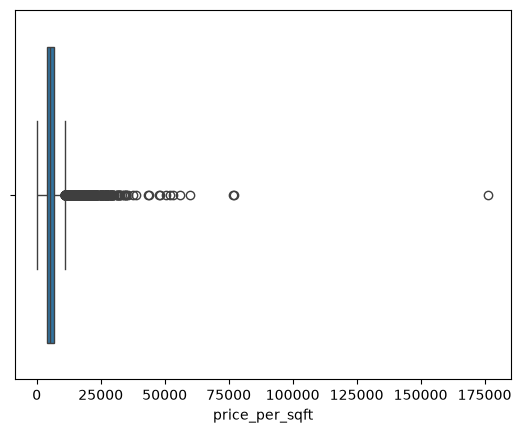

In [174]:
# sns.histplot(x='price_per_sqft', data=df)
sns.boxplot(x='price_per_sqft', data=df)

In [175]:
# handling outliers in price_per_sqft
q1 = df['price_per_sqft'].quantile(0.25)
q3 = df['price_per_sqft'].quantile(0.75)

IQR = q3 - q1

lower_bound = q1 - IQR * 0.5
upper_bound = q3 + IQR * 0.5

df = df[(df['price_per_sqft'] >= lower_bound) & (df['price_per_sqft'] <= upper_bound)]
df.info()

<class 'pandas.DataFrame'>
Index: 10350 entries, 0 to 13319
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   location        10350 non-null  str    
 1   size            10350 non-null  str    
 2   total_sqft      10350 non-null  float64
 3   bath            10350 non-null  float64
 4   price           10350 non-null  float64
 5   bhk             10350 non-null  int64  
 6   price_per_sqft  10350 non-null  float64
dtypes: float64(4), int64(1), str(2)
memory usage: 646.9 KB


<Axes: xlabel='price_per_sqft'>

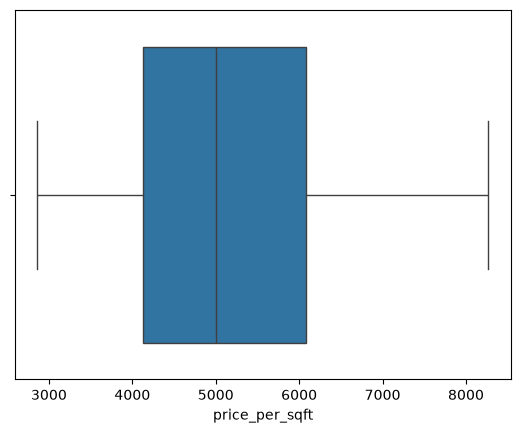

In [176]:
sns.boxplot(x='price_per_sqft', data=df)

In [177]:
# outliers in bhk
df = df[df['bhk'] <= 6]

In [178]:
# outliers in bath column
# keep rows where number of bathrooms is reasonable
df = df[df['bath'] < df['bhk'] + 2]

# it removes unrealistic rows where the number of bathrooms (bath) is suspiciously high compared to the number of bedrooms

df.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000


In [179]:
df = df.drop(['size', 'price_per_sqft'], axis=1)
df.head()

,location,total_sqft,bath,price,bhk
0,Electronic City Phase II,1056.0,2.0,39.07,2
1,Chikka Tirupathi,2600.0,5.0,120.00,4
2,Uttarahalli,1440.0,2.0,62.00,3
3,Lingadheeranahalli,1521.0,3.0,95.00,3
4,Kothanur,1200.0,2.0,51.00,2


In [180]:
df.reset_index(inplace=True) # resets the DataFrame index to the original state: 0, 1, 2, 3
df = df.drop('index', axis=1)

In [181]:
cleaned = df.copy()

In [182]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder() # object of LabelEncoder class
# imports the LabelEncoder class from the sklearn.preprocessing module
# LabelEncoder is used to convert categorical values (text) into numerical values

df['location'] = encoder.fit_transform(df[['location']]) # learns all the unique categories, replaces the text values with corresponding values

/home/akriti/Desktop/da-ai-training/venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [183]:
# divide data into X and y
X = df.drop('price', axis=1)
y = df['price']

# split data into training and testing data
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

In [184]:
model = RandomForestRegressor(random_state=42)
params = {
    "n_estimators": [100, 150, 200, 250, 300],
    "max_depth": [3, 4, 5, 6]
}

grid = GridSearchCV(estimator=model, param_grid=params, cv=5)
grid.fit(Xtrain, ytrain)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 4, ...], 'n_estimators': [100, 150, ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information

In [185]:
print("Best params: ", grid.best_params_)
print("Best score: ", grid.best_score_)

Best params:  {'max_depth': 6, 'n_estimators': 300}
Best score:  0.8355713454084395


In [186]:
print("Training efficiency: ", round(grid.score(Xtrain, ytrain) * 100, 2))
print("Testing efficiency: ", round(grid.score(Xtest, ytest) * 100, 2))

Training efficiency:  88.44
Testing efficiency:  84.01


In [187]:
ypred = grid.predict(Xtest)

In [188]:
print("R2: ", round(r2_score(ytest, ypred) * 100, 2))
print("Mean Absolute Error: ", mean_absolute_error(ytest, ypred))

R2:  84.01
Mean Absolute Error:  13.950445514191152


In [189]:
with open('RFmodel.pkl', 'wb') as file:
    pickle.dump(grid, file)

In [190]:
df.head()

,location,total_sqft,bath,price,bhk
0,78,1056.0,2.0,39.07,2
1,60,2600.0,5.0,120.00,4
2,226,1440.0,2.0,62.00,3
3,158,1521.0,3.0,95.00,3
4,150,1200.0,2.0,51.00,2


In [191]:
cleaned['encoded_loc'] = df['location']

In [192]:
df.describe()

,location,total_sqft,bath,price,bhk
count,10230.000000,10230.00000,10230.000000,10230.000000,10230.000000
mean,142.077810,1432.13379,2.367937,76.218467,2.495992
std,67.587302,773.66501,0.779985,54.319457,0.753740
min,0.000000,300.00000,1.000000,10.000000,1.000000
25%,92.000000,1100.00000,2.000000,47.000000,2.000000
50%,160.000000,1256.50000,2.000000,64.000000,2.000000
75%,193.000000,1577.00000,3.000000,89.112500,3.000000
max,240.000000,30400.00000,7.000000,2100.000000,6.000000


In [193]:
df.bath.unique()

array([2., 5., 3., 4., 1., 6., 7.])

In [195]:
df.shape

(10230, 5)

In [196]:
df.sample(5)

,location,total_sqft,bath,price,bhk
794,100,1420.0,2.0,75.0,2
9192,76,2710.0,3.0,177.0,3
2433,28,1012.0,2.0,75.0,2
465,184,1260.0,2.0,45.0,2
4970,184,1065.0,2.0,45.0,2
